# Visualize GlyphazznStage1Dataset

In [1]:
from thesis.dataset import GlyphazznStage1Dataset
import torch
import matplotlib.pyplot as plt
import numpy as np
import string
from thesis.utils import svg_to_tensor
from torchvision.utils import make_grid
min_len = 1.
max_len = 7.5

ds = GlyphazznStage1Dataset(top_level_dir="/scratch2/moritz_data/glyphazzn/svgs_simplified",
                            channels=3,
                            width=128,
                            train = True,
                            subset = "all",
                            individual_min_length=min_len,
                            individual_max_length=max_len)

/home/mfeuerpfeil/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def show(sample):
    grid_image = make_grid(sample, nrow=8, padding=2, normalize=True)

    # Plot the grid image
    plt.imshow(grid_image.permute(1, 2, 0))
    plt.axis('off')
    plt.show()

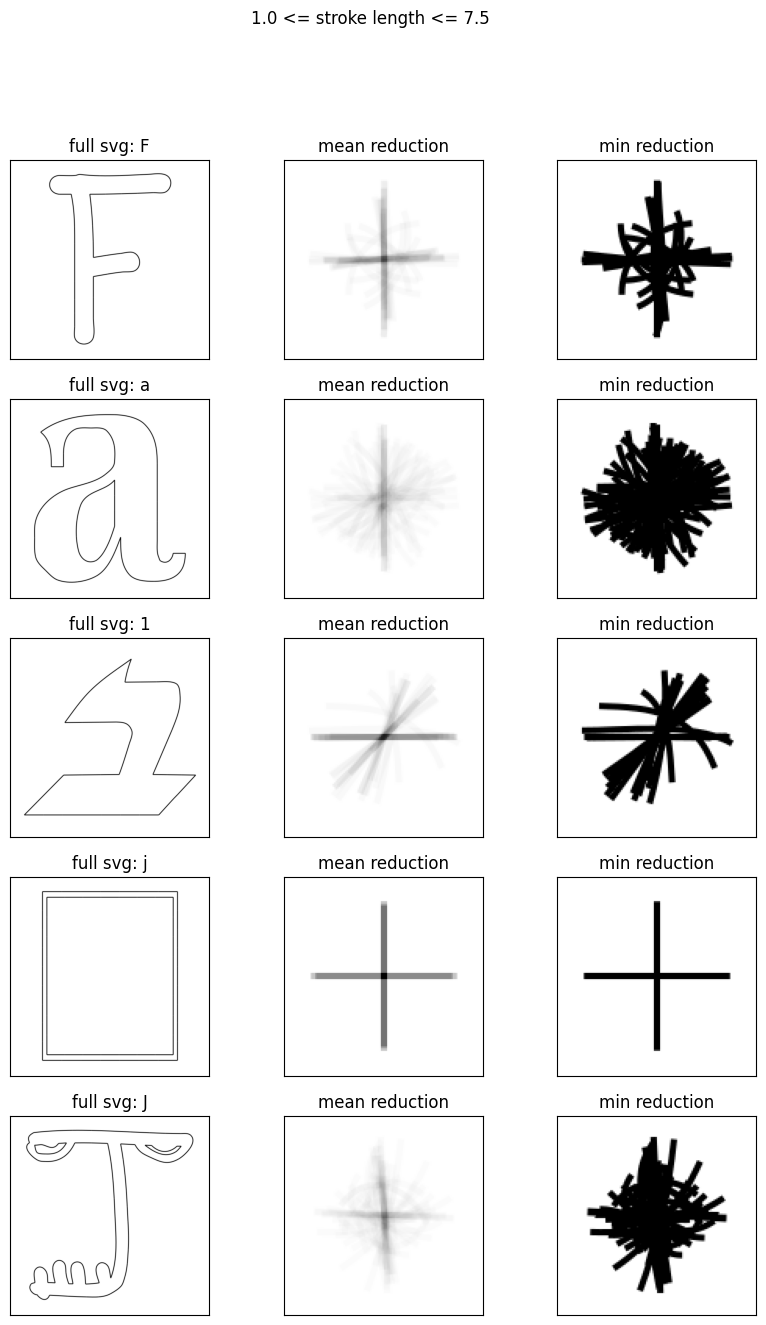

In [3]:
random_indices = np.random.randint(0, len(ds), size=5)

fig, axs = plt.subplots(5, 3, figsize=(10, 15))
fig.suptitle(f"{min_len} <= stroke length <= {max_len}")

for i, random_idx in enumerate(random_indices):
    example = ds[random_idx]
    full_svg = ds._get_full_svg_drawing(random_idx, as_tensor=True)
    class_char = string.printable[example[1][0].int().item()]

    mean_reduction = torch.mean(example[0], dim=0)
    min_reduction = torch.min(example[0], dim=0)[0]

    axs[i, 0].imshow(full_svg.permute(1, 2, 0))
    axs[i, 0].set_title(f"full svg: {class_char}")
    axs[i, 0].set_xticks([])
    axs[i, 0].set_yticks([])
    
    axs[i, 1].imshow(mean_reduction.permute(1, 2, 0))
    axs[i, 1].set_title("mean reduction")
    axs[i, 1].set_xticks([])
    axs[i, 1].set_yticks([])
    
    axs[i, 2].imshow(min_reduction.permute(1, 2, 0))
    axs[i, 2].set_title("min reduction")
    axs[i, 2].set_xticks([])
    axs[i, 2].set_yticks([])

# plt.savefig(f"images/stage1data/data_sample_{random_indices[0] + random_indices[1]}.png")
plt.show()

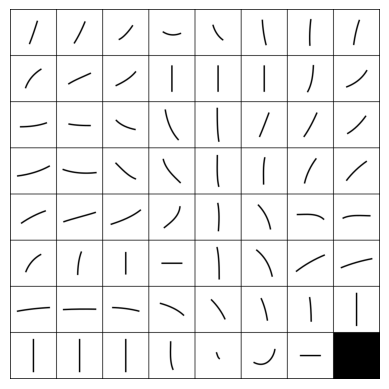

In [4]:
example = ds[random_indices[1]]
show(example[0])